In [ ]:
# Step 1: Memastikan semua library yang diperlukan sudah terinstal
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Akselerasi GPU (jika tersedia)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"artikaasd","key":"91e162b0a3e7e84d4400de590f59ad8d"}'}

In [ ]:
# Buat folder .kaggle kalau belum ada
!mkdir -p ~/.kaggle

# Pindahkan dan rename file supaya namanya jadi kaggle.json
!mv "kaggle.json" ~/.kaggle/kaggle.json

# Set permission file supaya aman
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c responsi-komputasi-statistika-2

 99% 1.61G/1.63G [00:11<00:00, 248MB/s]
100% 1.63G/1.63G [00:11<00:00, 148MB/s]


In [ ]:
!unzip responsi-komputasi-statistika-2.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset-Responsi/Train/rottenpotato/p_r305.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r306.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r307.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r308.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r309.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r310.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r311.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r312.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r313.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r314.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r315.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r316.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r317.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r318.png  
  inflating: Dataset-Responsi/Train/rottenpotato/p_r319.png  
  inflating: Datase

In [ ]:
!ls

Dataset-Responsi  responsi-komputasi-statistika-2.zip  sample_data


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),  # Ukuran gambar diubah menjadi 224x224
    transforms.RandomHorizontalFlip(),  # Horizontal flip secara acak
    transforms.RandomRotation(15),  # Rotasi gambar secara acak hingga 15 derajat
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Perubahan warna secara acak
    transforms.ToTensor(),  # Mengubah gambar menjadi tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalisasi berdasarkan ImageNet
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),  # Ukuran gambar diubah menjadi 224x224
    transforms.ToTensor(),  # Mengubah gambar menjadi tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalisasi berdasarkan ImageNet
])


# Load train dataset pakai ImageFolder (ada label)
train_dir = 'Dataset-Responsi/Train'
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Custom Dataset untuk test (tanpa label)
class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_files = os.listdir(test_dir)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name  # Return gambar dan nama file

test_dir = 'Dataset-Responsi/Test'
test_dataset = TestDataset(test_dir, transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Contoh cek batch train
images, labels = next(iter(train_loader))
print(images.shape, labels[:5])

# Contoh cek batch test
test_images, test_filenames = next(iter(test_loader))
print(test_images.shape, test_filenames[:5])


torch.Size([32, 3, 224, 224]) tensor([3, 0, 3, 0, 7])
torch.Size([32, 3, 224, 224]) ('img_0384.png', 'img_0875.png', 'img_0120.png', 'img_0999.png', 'img_0010.png')


In [ ]:
# Mengecek ukuran dataset
print(f"Jumlah gambar dalam dataset train: {len(train_dataset)}")
print(f"Jumlah gambar dalam dataset test: {len(test_dataset)}")

Jumlah gambar dalam dataset train: 13754
Jumlah gambar dalam dataset test: 1142


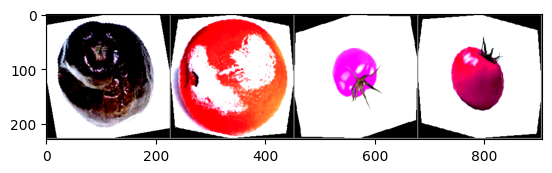

Filenames: tensor([4, 5, 3, 3])
Ukuran gambar: torch.Size([3, 224, 224])


In [ ]:
# Step 3: Eksplorasi dataset
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Ambil beberapa gambar dari dataset
trainloader = torch.utils.data.DataLoader(train_loader, batch_size=4, shuffle=True)

dataiter = iter(train_loader) # Ambil iterator dari trainloader
images, filenames = next(dataiter) # Get images and filenames
imshow(torchvision.utils.make_grid(images[:4])) # Tampilkan 4 gambar pertama
print(f"Filenames: {filenames[:4]}") # Print filenames instead of labels
print(f"Ukuran gambar: {images[0].shape}")

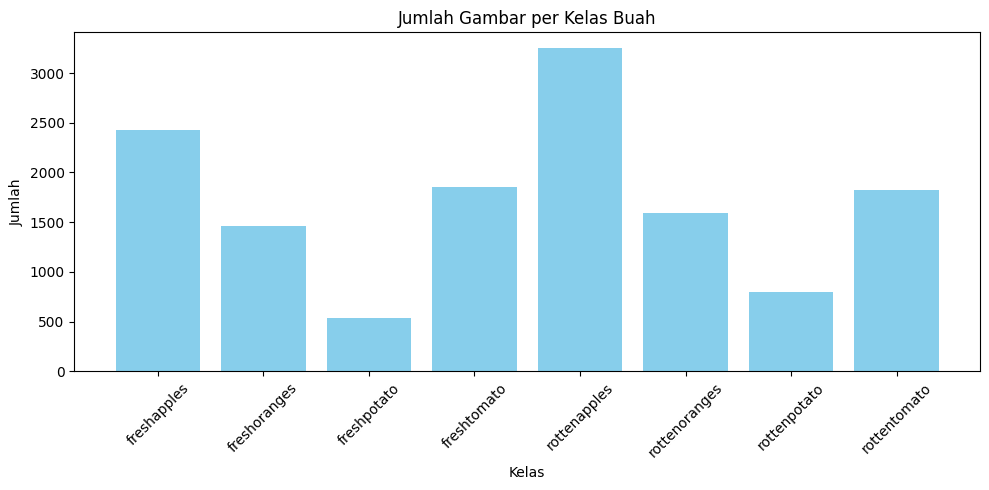

In [ ]:
# Hitung jumlah gambar per kelas
labels = train_dataset.targets
classes = train_dataset.classes
counts = [labels.count(i) for i in range(len(classes))]

# Plot barchart sederhana
plt.figure(figsize=(10, 5))
plt.bar(classes, counts, color='skyblue')
plt.title("Jumlah Gambar per Kelas Buah")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
classes = train_dataset.classes
classes

['freshapples',
 'freshoranges',
 'freshpotato',
 'freshtomato',
 'rottenapples',
 'rottenoranges',
 'rottenpotato',
 'rottentomato']

In [ ]:
# Step 4: Membuat model CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # (3, 32, 32) → (16, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (16, 32, 32) → (16, 16, 16)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # (16, 16, 16) → (32, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # (32, 16, 16) → (32, 8, 8)
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=32 * 56 * 56, out_features=128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)                      # ekstraksi fitur
        x = x.view(x.size(0), -1)                 # flatten: (batch_size, 32*8*8); -1 otomatis menghitung dimensi selain batch_size
        x = self.classifier(x)                    # klasifikasi
        return x

In [ ]:
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss() # Loss function untuk multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
data_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
train_path = '/content/Dataset-Responsi/Train'
train_dataset = datasets.ImageFolder(root=train_path, transform=data_transform)

In [ ]:
import torch
import torchvision
from torch import nn, optim
from torch.optim import AdamW
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os

In [ ]:
# === Handle Class Imbalance ===
from collections import Counter
class_counts = Counter([label for _, label in train_dataset])
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for _, label in train_dataset]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)

In [ ]:
# === Load Validation Dataset ===
val_path = '/content/Dataset-Responsi/Validation'
val_dataset = datasets.ImageFolder(root=val_path, transform=data_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# === Initialize Pretrained Model ===
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s]


In [ ]:
# Freeze all layers except the last few
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Modify Fully Connected Layer
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, len(train_dataset.classes))
)

model = model.to(device)

In [ ]:
# === Define Loss Function and Optimizer ===
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)


In [ ]:
# === Training with Early Stopping ===
num_epochs = 10
best_val_accuracy = 0
patience = 3
stopping_counter = 0

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

# Cetak nilai epoch dan rata-rata loss
avg_loss = epoch_loss / len(train_loader)
print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [10/10], Loss: 0.4945


In [ ]:
# Validation Step
model.eval()
correct_predictions = 0
total_predictions = 0
with torch.no_grad():
      for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total_predictions += labels.size(0)
            correct_predictions += (preds == labels).sum().item()

val_accuracy = correct_predictions / total_predictions
print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}")

Epoch 10/10, Loss: 0.4945, Val Accuracy: 0.9970


In [ ]:
# Assume inside a for loop for epochs
for epoch in range(num_epochs):
    # Validation logic here...
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        stopping_counter = 0
        torch.save(model.state_dict(), "best_resnet_model.pth")
    else:
        stopping_counter += 1
        if stopping_counter >= patience:
            print("Early stopping triggered.")
            break  # Correct placement inside the loop

Early stopping triggered.


In [ ]:
# === Load Test Dataset ===
class CustomTestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.image_names = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_names[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.image_names[idx]

In [ ]:
# Test Transformations
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_path = '/content/Dataset-Responsi/Test'
test_dataset = CustomTestDataset(test_path, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# === Load Best Model ===
model.load_state_dict(torch.load("best_resnet_model.pth"))
model.eval()

# === Predict on Test Dataset ===
class_mapping = {cls: idx + 1 for idx, cls in enumerate(train_dataset.classes)}
results = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for fname, pred in zip(filenames, preds):
            results.append({
                "image": fname,
                "label": class_mapping[train_dataset.classes[pred]]
            })

In [ ]:
# Save Predictions
import pandas as pd

results_df = pd.DataFrame(results)
results_df.to_csv("Predicted_Test_Results.csv", index=False)
print("Predictions saved to Predicted_Test_Results.csv")

# === Compare with Ground Truth ===
ground_truth_path = "/content/Hasil_Prediksi_Test(1).csv"
try:
    ground_truth = pd.read_csv(ground_truth_path)
    matching_labels = results_df['label'] == ground_truth['label']
    accuracy_percentage = matching_labels.mean() * 100

    print(f"Matching Labels: {accuracy_percentage:.2f}%")

    # Display Differences
    differences = results_df[~matching_labels].copy()
    differences['Ground Truth'] = ground_truth.loc[~matching_labels, 'label']
    print(differences.head())
except FileNotFoundError:
    print(f"Error: File '{ground_truth_path}' not found. Please ensure the file exists and the path is correct.")

Predictions saved to Predicted_Test_Results.csv
Error: File '/content/Hasil_Prediksi_Test(1).csv' not found. Please ensure the file exists and the path is correct.


In [ ]:
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validasi
    model.eval()
    correct_predictions = 0
    total_predictions = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total_predictions += labels.size(0)
            correct_predictions += (preds == labels).sum().item()

    val_accuracy = correct_predictions / total_predictions
    val_accuracies.append(val_accuracy * 100)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Val Accuracy: {val_accuracy:.2f}")

Epoch [1/10], Loss: 0.4902, Val Accuracy: 1.00
Epoch [2/10], Loss: 0.4907, Val Accuracy: 1.00
Epoch [3/10], Loss: 0.4900, Val Accuracy: 0.99
Epoch [4/10], Loss: 0.4906, Val Accuracy: 1.00
Epoch [5/10], Loss: 0.4958, Val Accuracy: 1.00
Epoch [6/10], Loss: 0.4897, Val Accuracy: 1.00
Epoch [7/10], Loss: 0.4884, Val Accuracy: 1.00
Epoch [8/10], Loss: 0.4892, Val Accuracy: 1.00
Epoch [9/10], Loss: 0.4864, Val Accuracy: 1.00
Epoch [10/10], Loss: 0.4898, Val Accuracy: 1.00


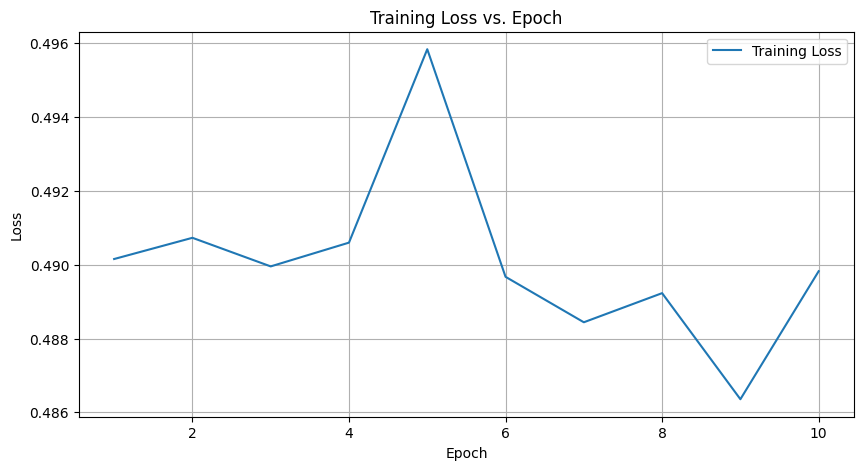

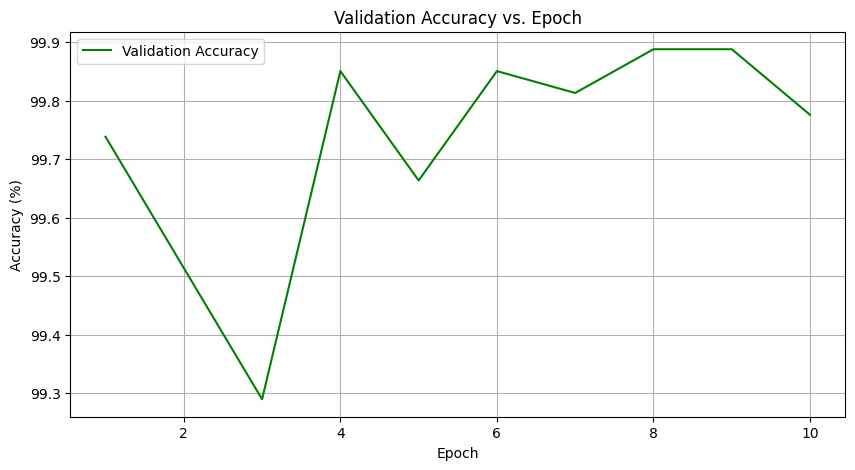

In [ ]:
# Plot training loss
import matplotlib.pyplot as plt

# Ensure train_losses and val_accuracies are defined
try:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss vs. Epoch')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot validation accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Validation Accuracy vs. Epoch')
    plt.legend()
    plt.grid()
    plt.show()

except NameError as e:
    print(f"Error: {e}. Ensure 'train_losses' and 'val_accuracies' are correctly defined and populated during training.")